# Introduction
We give an example on how to solve a constrained binary program with our Custom Penalty Solver.

# How to formulate the problem
We use the 0-1 Knapasack problem as an example. It has integer inequality constraints, which is best suited for the custom penalty method (no need slack variables). The Knapsack problem can be formulated as
\begin{align*}
    \max_{x_i\in\{0,1\}} & \sum_{i=1}^n v_i x_i \\
    \text{s.t.} & \sum_{i=1}^n w_i x_i \leq W
\end{align*}
with $v_i$ the values of item $i$, $w_i$ the weight of item $i$ and the capacity $W$ of the knapsack.

We recommend using `docplex` to formulate the program for its readability, then use `from_docplex_mp` to convert to `QuadraticProgram`. For example, now we have the above problem with the following values:

| $v_i$ | 5 | 10 | 20 | 30 | 35 | 40 | 
| --- | --- | -- | -- | -- | -- | -- | 
| $w_i$ | 3 | 5  | 6  | 7  | 9  | 10 |

with the capacity $W=14$.

In [1]:
from docplex.mp.model import Model
from qiskit_optimization.translators import from_docplex_mp

num_items = 6
model = Model(name='Knapsack Problem')
x = model.binary_var_list(num_items, name='x')

v = [5, 10, 20, 30, 35, 40] # values of the items
w = [3, 5, 6, 7, 9, 10] # weights of the items
capacity = 14

# Define the objective function
model.maximize(model.sum(v[i] * x[i] for i in range(num_items)))
model.add_constraint(model.sum(w[i] * x[i] for i in range(num_items)) <= capacity)

qp = from_docplex_mp(model)
print(qp.prettyprint())

Problem name: Knapsack Problem

Maximize
  5*x_0 + 10*x_1 + 20*x_2 + 30*x_3 + 35*x_4 + 40*x_5

Subject to
  Linear constraints (1)
    3*x_0 + 5*x_1 + 6*x_2 + 7*x_3 + 9*x_4 + 10*x_5 <= 14  'c0'

  Binary variables (6)
    x_0 x_1 x_2 x_3 x_4 x_5



# Defining the ansatz
We use the $R_Y+CZ$ ansatz by default. Since we're solving using VQE, the users are free to choose their own ansatz.

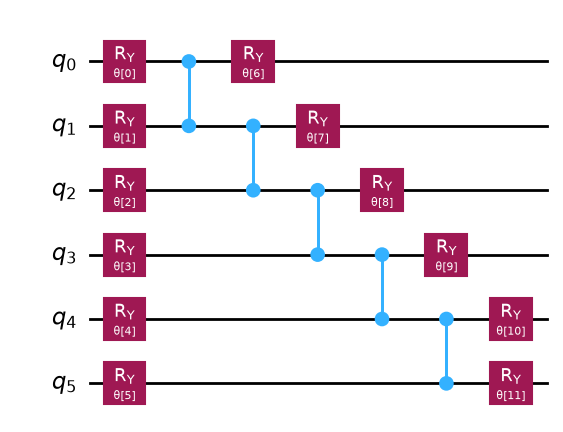

In [2]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

num_qubits = num_items
ansatz = QuantumCircuit(num_qubits)

num_params = 2 * num_qubits
params = ParameterVector('\u03b8', num_params)

for i in range(num_qubits):
    ansatz.ry(params[i], i)

for i in range(num_qubits - 1):
    ansatz.cz(i, i + 1)

for i in range(num_qubits):
    ansatz.ry(params[i + num_qubits], i)

ansatz.draw('mpl')

*Important: You do not need to include the measurement operators at the end of the circuit as the solver will do it automatically.

# Custom penalty
Consider a constrained binary minimization program:
\begin{align*}
    \min_{x\in\{0,1\}^n} & \quad f(x) \\
    \text{s.t.} &\quad  g_i(x) = 0, \quad i=1,...,k\\
    & \quad h_j(x) \leq 0, \quad j=1,...,l
\end{align*}

We formulate the penalized unconstrained loss function $\mathcal{L}$ as
$$ \mathcal{L}(x) = f(x) + \sum_{i=1}^k \lambda_i [g_i(x)]^2 + \sum_{j=1}^l \mu_j \xi[h_j(x)] $$

$\lambda$ and $\mu$ are the penalty factors to decide how much to penalize each constraint.
This can be passed as a list into the `penalty_mult` argument during the instantiation of the solver object.
The sequence of the penalty factors follows the one defined in your `QuadraticProgram`, with the linear constraints followed by the quadratic constraints.

$\xi(\cdot)$ is the penalty function that we want to implement. It should separate the solutions by their feasibilities, i.e. $h(x)<=0$ and $h(x)>0$.
A good example for this is the Heaviside step function which is defined as
$$
\Theta(x) = 
\begin{cases}
    0 & \text{if } x \leq 0 \\
    1 & \text{if } x > 0
\end{cases}
$$
Feel free to try out other penalty functions! Pass your function into the `penalty_func` argument.

In [11]:
import numpy as np
from custom_penalty import CustomPenaltySolver

# Instantiate the CPS
cps = CustomPenaltySolver(
    qp,                                             # quadratic program
    ansatz=ansatz,                                  # ansatz circuit
    penalty_mult=[150],                             # penalty factor
    penalty_func=(lambda x: np.heaviside(x, 0)),    # penalty function
    default_shots=2048,                             # no. of shots for the sampler
)

# Sampling
Two sampling methods are provided in the solver: finite sampling (FS) and Conditional Value-at-Risk (CVaR). 
FS is a traditional method where we estimate the expectation of the Hamiltonian (the loss) using Monte Carlo Simulation, the estimator of the expectation $\hat{E}$ is given as
$$
\hat{E}(\theta) = \frac{1}{M} \sum_{m=1}^M \mathcal{L}(x^{(m)}(\theta)).
$$
This is similar to flipping a coin many times to get the probability of getting heads and tails. We sample $x^{(m)}$ as the result $m$-th shot from the quantum circuit for $M$ times.
$x^{(m)}$ is then passed into our loss fuction $\mathcal{L}(x^{(m)})$ to obtain the estimated expectation.

The other method we want to introduce is the Conditional Value-at-Risk (CVaR). The CVaR defines a loss function that only consider a portion of the best samples in computing the loss.
Before computing the loss, the samples must be sorted in the order of $\mathcal{L}(x^{(1)}) \leq \mathcal{L}(x^{(2)}) \leq ... \leq \mathcal{L}(x^{(M)})$.
The CVaR loss function is then defined as 
$$
\text{CVaR}(\alpha;\theta) = \frac{1}{\lceil\alpha M\rceil} \sum_{m=1}^{\lceil\alpha M\rceil} \mathcal{L}(x^{(m)}(\theta)).
$$
The loss only considers the best $\lceil\alpha M\rceil$ samples among the $M$ samples. You can refer to the original work of CVaR [here](https://arxiv.org/abs/1907.04769).

In [12]:
# Solve the problem
result = cps.solve(
    initial_point=None,     # initial parameter, None for random initialization
    sampling_method='fs',   # sampling method, either 'fs' or 'cvar'
    optimizer='powell',     # scipy optimizer
)

# Print important results
print('Loss:', result.fun)
print('Solution:', cps.optimal_solution)
print('Objective:', cps.qp.objective.evaluate(cps.optimal_solution))
print('Feasibility:', cps.qp.is_feasible(cps.optimal_solution))

Loss: -49.73388671875
Solution: [0, 0, 1, 1, 0, 0]
Objective: 50.0
Feasibility: True


Does the solution meet your expectation? Check it with a classical solver.

In [13]:
grb_obj, grb_sol = cps.solve_gurobi()

print('Gurobi Objective:', grb_obj)
print('Gurobi Solution:', grb_sol)

Restricted license - for non-production use only - expires 2027-11-29
Gurobi Objective: 50.0
Gurobi Solution: [0. 0. 1. 1. 0. 0.]
